# 04_multimodal_product_fusion_final.ipynb

Enterprise multimodal product fusion pipeline using Visual Semantic Intelligence V2/V3 outputs and validated embeddings.

In [1]:

!pip install -q pyarrow scikit-learn


In [2]:

import os
import json
import warnings

import numpy as np
import pandas as pd

from tqdm.auto import tqdm
from collections import Counter

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 300)


In [3]:

BASE_DIR = "/kaggle/working"

FUSION_DIR = (
    f"{BASE_DIR}/multimodal_product_fusion_final"
)

os.makedirs(
    FUSION_DIR,
    exist_ok=True
)

print(FUSION_DIR)


/kaggle/working/multimodal_product_fusion_final


## Stage 1 — Load Visual Semantic Intelligence

In [4]:

visual_df = pd.read_parquet(

    "/kaggle/input/notebooks/hanafudaearring/visual-semantic-intelligence-v3/visual_semantic_v3/visual_semantic_v3.parquet"
)

print(
    "VISUAL DF:",
    visual_df.shape
)

visual_df.head()


VISUAL DF: (4343, 23)


,asin,image_path_runtime,caption,quality_score,embedding_health_score,semantic_cluster,is_duplicate,dominant_rgb,dominant_color_name,color_r,color_g,color_b,logo_keywords,logo_detected,color_palette,primary_color,color_diversity,style_tags,edge_density,brightness,whitespace_ratio,visual_uniqueness,catalog_media_score
0,B0B59BJG6Y,/kaggle/input/notebooks/hanafudaearring/media-...,men ' s polo shirt,0.326877,0.671388,20,False,"[254, 254, 254]",white,254,254,254,[],False,"[[254, 254, 254], [55, 56, 59], [109, 157, 203...",white,5,[casual],0.027805,0.676664,0.380420,0.068922,0.539282
1,B0B59BJG6Y,/kaggle/input/notebooks/hanafudaearring/media-...,a man wearing a black polo shirt with a smile ...,0.373938,0.556625,3,False,"[247, 247, 247]",white,247,247,247,[],False,"[[254, 254, 254], [125, 101, 91], [183, 171, 1...",white,5,[casual],0.035520,0.764927,0.441000,0.083564,0.496521
2,B0B59BJG6Y,/kaggle/input/notebooks/hanafudaearring/media-...,a man wearing a grey polo shirt and white pants,0.358860,0.502382,21,False,"[91, 85, 83]",gray,91,85,83,[],False,"[[224, 220, 217], [109, 101, 99], [179, 163, 1...",pink,5,[casual],0.046040,0.723609,0.506732,0.086588,0.451503
3,B0B59BJG6Y,/kaggle/input/notebooks/hanafudaearring/media-...,a man walking with a golf bag,0.337530,0.614620,16,False,"[154, 158, 131]",gray,154,158,131,[],False,"[[45, 67, 22], [248, 249, 249], [115, 114, 95]...",green,5,[],0.054984,0.622006,0.308232,0.093420,0.547973
4,B0B59BJG6Y,/kaggle/input/notebooks/hanafudaearring/media-...,a man standing on the beach with his hands in ...,0.362279,0.631133,23,False,"[113, 134, 169]",gray,113,134,169,[],False,"[[245, 249, 249], [80, 128, 188], [155, 118, 1...",white,5,[],0.030192,0.793791,0.563976,0.084040,0.476479


In [5]:

visual_df.columns.tolist()


['asin',
 'image_path_runtime',
 'caption',
 'quality_score',
 'embedding_health_score',
 'semantic_cluster',
 'is_duplicate',
 'dominant_rgb',
 'dominant_color_name',
 'color_r',
 'color_g',
 'color_b',
 'logo_keywords',
 'logo_detected',
 'color_palette',
 'primary_color',
 'color_diversity',
 'style_tags',
 'edge_density',
 'brightness',
 'whitespace_ratio',
 'visual_uniqueness',
 'catalog_media_score']

## Stage 2 — Load Embeddings

In [6]:

fusion_embeddings = np.load(

    "/kaggle/input/notebooks/hanafudaearring/embedding-validation/artifacts_2/v2/validated_fusion_embeddings.npy"
)

print(
    fusion_embeddings.shape
)


(4343, 512)


In [7]:

visual_df["embedding_index"] = np.arange(
    len(visual_df)
)


## Stage 3 — Product Grouping

In [8]:

asin_groups = visual_df.groupby(
    "asin"
)

print(
    "TOTAL PRODUCTS:",
    len(asin_groups)
)


TOTAL PRODUCTS: 728


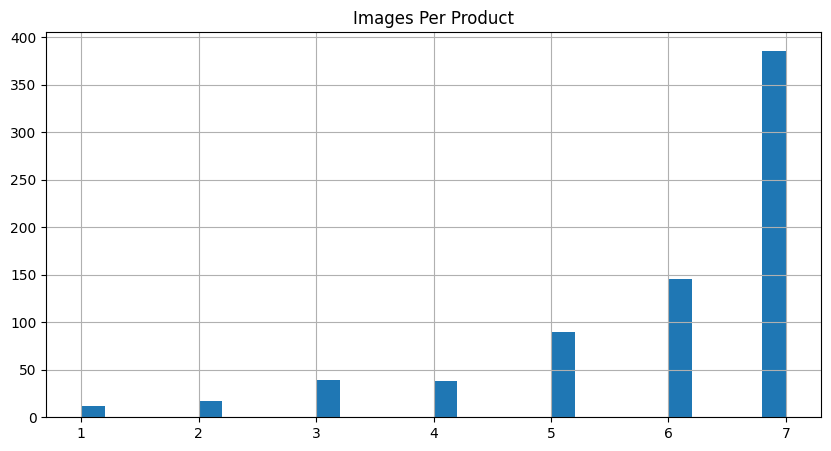

In [9]:

plt.figure(figsize=(10,5))

asin_groups.size().hist(
    bins=30
)

plt.title(
    "Images Per Product"
)

plt.show()


## Stage 4 — Fusion Utilities

In [10]:

def safe_mean(values):

    values = [
        v for v in values
        if pd.notnull(v)
    ]

    if len(values) == 0:
        return None

    return float(np.mean(values))


def flatten_lists(series):

    out = []

    for item in series:

        if isinstance(item, list):

            out.extend(item)

    return out


## Stage 5 — Product Fusion

In [11]:

product_records = []

for asin, group in tqdm(asin_groups):

    embedding_indices = (
        group[
            "embedding_index"
        ].tolist()
    )

    product_embeddings = (
        fusion_embeddings[
            embedding_indices
        ]
    )

    fused_embedding = np.mean(
        product_embeddings,
        axis=0
    )

    styles = flatten_lists(
        group.get(
            "style_tags",
            []
        )
    )

    logos = flatten_lists(
        group.get(
            "logo_keywords",
            []
        )
    )

    colors = (
        group.get(
            "primary_color",
            pd.Series(dtype=str)
        )
        .dropna()
        .astype(str)
        .tolist()
    )

    dominant_color = (

        Counter(colors)
        .most_common(1)[0][0]

        if len(colors) > 0
        else "unknown"
    )

    categories = (
        group.get(
            "visual_category",
            pd.Series(dtype=str)
        )
        .dropna()
        .astype(str)
        .tolist()
    )

    dominant_category = (

        Counter(categories)
        .most_common(1)[0][0]

        if len(categories) > 0
        else "unknown"
    )

    product_records.append({

        "asin":
            asin,

        "image_count":
            len(group),

        "avg_quality_score":
            safe_mean(
                group[
                    "quality_score"
                ]
            ),

        "avg_embedding_health":
            safe_mean(
                group[
                    "embedding_health_score"
                ]
            ),

        "avg_media_score":
            safe_mean(
                group.get(
                    "catalog_media_score",
                    []
                )
            ),

        "duplicate_ratio":
            float(
                group[
                    "is_duplicate"
                ].mean()
            ),

        "color_diversity":
            len(set(colors)),

        "style_diversity":
            len(set(styles)),

        "logo_density":
            float(
                group.get(
                    "logo_detected",
                    pd.Series(dtype=float)
                ).mean()
            ) if "logo_detected" in group.columns else 0,

        "dominant_color":
            dominant_color,

        "dominant_visual_category":
            dominant_category,

        "top_styles":
            list(set(styles))[:10],

        "detected_logos":
            list(set(logos))[:10],

        "merged_caption":
            " | ".join(
                group[
                    "caption"
                ]
                .dropna()
                .astype(str)
                .tolist()[:10]
            ),

        "visual_uniqueness":
            safe_mean(
                group.get(
                    "visual_uniqueness",
                    []
                )
            ),

        "fused_embedding":
            fused_embedding
    })


  0%|          | 0/728 [00:00<?, ?it/s]

In [12]:

product_df = pd.DataFrame(
    product_records
)

print(
    product_df.shape
)

product_df.head()


(728, 16)


,asin,image_count,avg_quality_score,avg_embedding_health,avg_media_score,duplicate_ratio,color_diversity,style_diversity,logo_density,dominant_color,dominant_visual_category,top_styles,detected_logos,merged_caption,visual_uniqueness,fused_embedding
0,B00021NY28,6,0.356888,0.595175,0.462246,0.0,3,0,0.000000,white,unknown,[],[],a woman in a white top and black pants | a wom...,NaN,"[0.017875921, 0.02697452, -0.032951687, -0.005..."
1,B0006U6C0Q,7,0.331323,0.622507,0.490208,0.0,4,0,0.000000,white,unknown,[],[],a man in a blue shirt and jeans | a man in a b...,NaN,"[0.014319795, 0.020532222, -0.022347748, -0.00..."
2,B0007CKJSY,7,0.287760,0.616898,0.508821,0.0,4,0,0.000000,white,unknown,[],[],wr men ' s wr wr wr wr wr wr wr wr wr wr wr wr...,NaN,"[0.0085501205, 0.01536036, -0.01711279, -0.010..."
3,B0008EOG9E,3,0.384456,0.573370,0.403791,1.0,2,0,0.666667,white,unknown,[],[],"levi levi men ' s regular fit jeans, blue, 34w...",NaN,"[0.0031577311, 0.022369334, -0.0078112525, 0.0..."
4,B0008EOGAS,3,0.384456,0.576210,0.404737,1.0,2,0,0.666667,white,unknown,[],[],"levi levi men ' s regular fit jeans, blue, 34w...",NaN,"[0.008239375, 0.020316346, -0.0069890865, 0.01..."


## Stage 6 — Embedding Space

In [13]:

product_embeddings = np.vstack(

    product_df[
        "fused_embedding"
    ].values
)

print(
    product_embeddings.shape
)


(728, 512)


In [14]:

similarity_matrix = cosine_similarity(
    product_embeddings
)

similarity_matrix.shape


(728, 728)

In [15]:

pca = PCA(
    n_components=2
)

reduced_embeddings = pca.fit_transform(
    product_embeddings
)


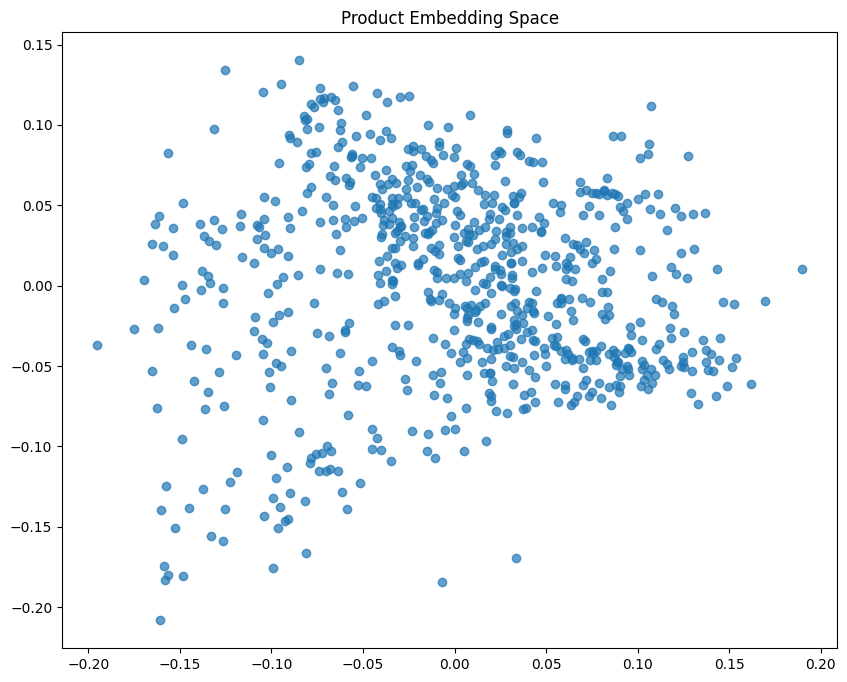

In [16]:

plt.figure(figsize=(10,8))

plt.scatter(

    reduced_embeddings[:,0],
    reduced_embeddings[:,1],

    alpha=0.7
)

plt.title(
    "Product Embedding Space"
)

plt.show()


## Stage 7 — Product Intelligence

In [17]:

product_df["product_intelligence_score"] = (

    (
        product_df[
            "avg_quality_score"
        ].fillna(0)

        +

        product_df[
            "avg_embedding_health"
        ].fillna(0)

        +

        product_df[
            "avg_media_score"
        ].fillna(0)

        +

        (
            1 -
            product_df[
                "duplicate_ratio"
            ]
        )
    ) / 4
)


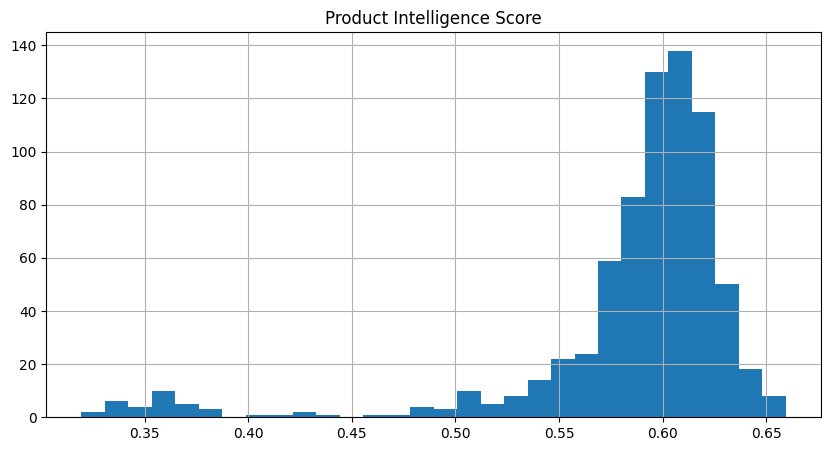

In [18]:

plt.figure(figsize=(10,5))

product_df[
    "product_intelligence_score"
].hist(
    bins=30
)

plt.title(
    "Product Intelligence Score"
)

plt.show()


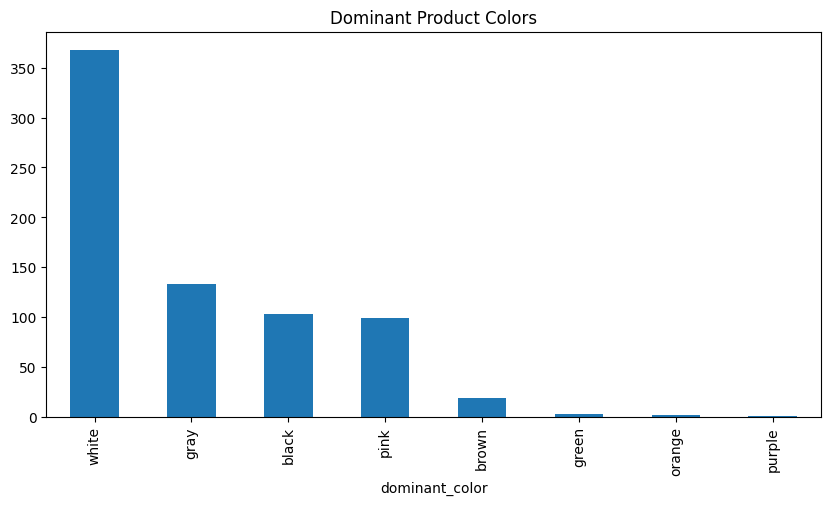

In [19]:

product_df[
    "dominant_color"
].value_counts().plot.bar(
    figsize=(10,5)
)

plt.title(
    "Dominant Product Colors"
)

plt.show()


## Stage 8 — Retrieval Index

In [20]:

retrieval_records = []

for idx, row in product_df.iterrows():

    sims = similarity_matrix[idx]

    top_indices = np.argsort(
        sims
    )[::-1][1:6]

    retrieval_records.append({

        "asin":
            row["asin"],

        "top_similar_asins":
            product_df.iloc[
                top_indices
            ]["asin"].tolist(),

        "top_similarities":
            sims[
                top_indices
            ].tolist()
    })


In [21]:

retrieval_df = pd.DataFrame(
    retrieval_records
)

retrieval_df.head()


,asin,top_similar_asins,top_similarities
0,B00021NY28,"[B09PDMRNNZ, B0C38W6M1C, B0D5WLQ9FZ, B073SLX23...","[0.9927945137023926, 0.989791989326477, 0.9878..."
1,B0006U6C0Q,"[B0CBL2WWBG, B07BHKQ8SM, B078LZL68J, B0D98NLXK...","[0.9937635064125061, 0.9899353384971619, 0.988..."
2,B0007CKJSY,"[B098KXZG2Z, B098QPTCF8, B07SH9F51B, B07PLVGLW...","[0.9899022579193115, 0.9886913299560547, 0.988..."
3,B0008EOG9E,"[B0008EOGAS, B07HNVR4ZD, B01IR7TZWG, B09NMPH8Y...","[0.992286205291748, 0.9780927896499634, 0.9753..."
4,B0008EOGAS,"[B0008EOG9E, B07HNVR4ZD, B01IR7TZWG, B01ISMKS7...","[0.992286205291748, 0.9839043617248535, 0.9797..."


## Stage 9 — Exports

In [22]:

product_df.to_parquet(

    f"{FUSION_DIR}/product_feature_store.parquet",

    index=False
)

retrieval_df.to_parquet(

    f"{FUSION_DIR}/product_retrieval_index.parquet",

    index=False
)

np.save(

    f"{FUSION_DIR}/product_embeddings.npy",

    product_embeddings
)

print(
    "EXPORTS COMPLETE"
)


EXPORTS COMPLETE


In [23]:

health_report = {

    "total_products":
        int(len(product_df)),

    "avg_images_per_product":
        float(
            product_df[
                "image_count"
            ].mean()
        ),

    "dominant_colors":
        int(
            product_df[
                "dominant_color"
            ].nunique()
        ),

    "products_with_logos":
        int(
            (
                product_df[
                    "logo_density"
                ] > 0
            ).sum()
        )
}

health_report


{'total_products': 728,
 'avg_images_per_product': 5.96565934065934,
 'dominant_colors': 8,
 'products_with_logos': 58}

In [24]:

with open(

    f"{FUSION_DIR}/fusion_health_report.json",

    "w"

) as f:

    json.dump(
        health_report,
        f,
        indent=4
    )

print("=" * 60)

print(
    "MULTIMODAL PRODUCT FUSION COMPLETE"
)

print("=" * 60)

print(
    "TOTAL PRODUCTS:",
    len(product_df)
)

print("=" * 60)


MULTIMODAL PRODUCT FUSION COMPLETE
TOTAL PRODUCTS: 728
